In [ ]:
# programa para testear los endpoints de demanda con diferentes combinaciones de parámetros
import requests
import pandas as pd
import time

BASE_URL = "https://apidatos.ree.es/es/datos"

widgets_demanda = [
    "evolucion",
    "variacion-componentes",
    "variacion-componentes-movil",
    "ire-general",
    "ire-general-anual",
    "ire-general-movil",
    "ire-industria",
    "ire-industria-anual",
    "ire-industria-movil",
    "ire-servicios",
    "ire-servicios-anual",
    "ire-servicios-movil",
    "ire-otras",
    "ire-otras-anual",
    "ire-otras-movil",
    "demanda-maxima-diaria",
    "demanda-maxima-horaria",
    "perdidas-transporte",
    "potencia-maxima-instantanea",
    "variacion-demanda",
    "potencia-maxima-instantanea-variacion",
    "potencia-maxima-instantanea-variacion-historico",
    "variacion-componentes-anual"
]

time_truncs = ["day", "month", "year"]

geo_ids = list(range(4, 22)) + [8741, 8742, 8743, 8744, 8745]

resultados = []

for widget in widgets_demanda:
    for time_trunc in time_truncs:
        for geo_id in geo_ids:
            
            url = f"{BASE_URL}/demanda/{widget}"
            
            params = {
                "start_date": "2024-01-01T00:00",
                "end_date": "2024-12-31T23:59",
                "time_trunc": time_trunc,
                "geo_trunc": "electric_system",
                "geo_limit": "ccaa",
                "geo_ids": str(geo_id)
            }
            
            response = requests.get(url, params=params)
            
            ok = response.status_code == 200
            
            resultados.append({
                "widget": widget,
                "time_trunc": time_trunc,
                "geo_id": geo_id,
                "status": response.status_code,
                "url": response.url,
                "preview": response.text[:200]
            })
            
            print(widget, time_trunc, geo_id, response.status_code)
            time.sleep(0.2)

df_tests = pd.DataFrame(resultados)
df_tests

evolucion day 4 400
evolucion day 5 400
evolucion day 6 400
evolucion day 7 400
evolucion day 8 400
evolucion day 9 400
evolucion day 10 400
evolucion day 11 400
evolucion day 12 400
evolucion day 13 400
evolucion day 14 400
evolucion day 15 400
evolucion day 16 400
evolucion day 17 400
evolucion day 18 400
evolucion day 19 400
evolucion day 20 400
evolucion day 21 400
evolucion day 8741 400
evolucion day 8742 400
evolucion day 8743 400
evolucion day 8744 400
evolucion day 8745 400
evolucion month 4 200
evolucion month 5 200
evolucion month 6 200
evolucion month 7 200
evolucion month 8 200
evolucion month 9 200
evolucion month 10 200
evolucion month 11 200
evolucion month 12 200
evolucion month 13 200
evolucion month 14 200
evolucion month 15 200
evolucion month 16 200
evolucion month 17 200
evolucion month 18 200
evolucion month 19 200
evolucion month 20 200
evolucion month 21 200
evolucion month 8741 200
evolucion month 8742 200
evolucion month 8743 200
evolucion month 8744 200
evolu

,widget,time_trunc,geo_id,status,url,preview
0,evolucion,day,4,400,https://apidatos.ree.es/es/datos/demanda/evolu...,"{""errors"":[{""status"":""400"",""title"":""Error Inte..."
1,evolucion,day,5,400,https://apidatos.ree.es/es/datos/demanda/evolu...,"{""errors"":[{""status"":""400"",""title"":""Error Inte..."
2,evolucion,day,6,400,https://apidatos.ree.es/es/datos/demanda/evolu...,"{""errors"":[{""status"":""400"",""title"":""Error Inte..."
3,evolucion,day,7,400,https://apidatos.ree.es/es/datos/demanda/evolu...,"{""errors"":[{""status"":""400"",""title"":""Error Inte..."
4,evolucion,day,8,400,https://apidatos.ree.es/es/datos/demanda/evolu...,"{""errors"":[{""status"":""400"",""title"":""Error Inte..."
...,...,...,...,...,...,...
1582,variacion-componentes-anual,year,8741,403,https://apidatos.ree.es/es/datos/demanda/varia...,"<html style=""height:100%""><head><META NAME=""RO..."
1583,variacion-componentes-anual,year,8742,403,https://apidatos.ree.es/es/datos/demanda/varia...,"<html style=""height:100%""><head><META NAME=""RO..."
1584,variacion-componentes-anual,year,8743,403,https://apidatos.ree.es/es/datos/demanda/varia...,"<html style=""height:100%""><head><META NAME=""RO..."
1585,variacion-componentes-anual,year,8744,403,https://apidatos.ree.es/es/datos/demanda/varia...,"<html style=""height:100%""><head><META NAME=""RO..."


In [ ]:
#filtrar solo los tests que han funcionado correctamente (status 200) 
df_ok = df_tests[df_tests["status"] == 200]

df_ok[["widget", "time_trunc", "geo_id", "status", "url"]]

,widget,time_trunc,geo_id,status,url
23,evolucion,month,4,200,https://apidatos.ree.es/es/datos/demanda/evolu...
24,evolucion,month,5,200,https://apidatos.ree.es/es/datos/demanda/evolu...
25,evolucion,month,6,200,https://apidatos.ree.es/es/datos/demanda/evolu...
26,evolucion,month,7,200,https://apidatos.ree.es/es/datos/demanda/evolu...
27,evolucion,month,8,200,https://apidatos.ree.es/es/datos/demanda/evolu...
28,evolucion,month,9,200,https://apidatos.ree.es/es/datos/demanda/evolu...
29,evolucion,month,10,200,https://apidatos.ree.es/es/datos/demanda/evolu...
30,evolucion,month,11,200,https://apidatos.ree.es/es/datos/demanda/evolu...
31,evolucion,month,12,200,https://apidatos.ree.es/es/datos/demanda/evolu...
32,evolucion,month,13,200,https://apidatos.ree.es/es/datos/demanda/evolu...


In [ ]:
#Guardar los resultados de los tests en un csv
df_tests.to_csv("test_endpoints_demanda_regional.csv", index=False)

In [ ]:
# programa para descargar los datos de demanda regional de los últimos 10 años 
import requests
import pandas as pd
import time

url = "https://apidatos.ree.es/es/datos/demanda/evolucion"

ccaa_ids = {
    "Andalucía": 4,
    "Aragón": 5,
    "Castilla y León": 6,
    "Castilla-La Mancha": 7,
    "La Rioja": 8,
    "Cataluña": 9,
    "Navarra": 10,
    "Asturias": 11,
    "Cantabria": 12,
    "Madrid": 13,
    "Murcia": 14,
    "Comunidad Valenciana": 15,
    "Extremadura": 16,
    "Galicia": 17,
    "País Vasco": 20,
    "Canarias": 8742,
    "Baleares": 8743,
    "Ceuta": 8744,
    "Melilla": 8745
}

all_regions = []

for region, geo_id in ccaa_ids.items():
    for year in range(2016, 2026):

        print(f"Descargando {region} - {year}...")

        params = {
            "start_date": f"{year}-01-01T00:00",
            "end_date": f"{year}-12-31T23:59",
            "time_trunc": "month",
            "geo_trunc": "electric_system",
            "geo_limit": "ccaa",
            "geo_ids": str(geo_id)
        }

        response = requests.get(url, params=params)

        print("Status:", response.status_code)

        if response.status_code == 200:
            data = response.json()
            values = data["included"][0]["attributes"]["values"]

            temp = pd.DataFrame(values)
            temp["region"] = region
            temp["geo_id"] = geo_id
            temp["year_requested"] = year

            all_regions.append(temp)

            print(f"{len(temp)} registros")

        else:
            print("ERROR")
            print(response.text[:300])

        time.sleep(0.3)

Descargando Andalucía - 2016...
Status: 200
12 registros
Descargando Andalucía - 2017...
Status: 200
12 registros
Descargando Andalucía - 2018...
Status: 200
12 registros
Descargando Andalucía - 2019...
Status: 200
12 registros
Descargando Andalucía - 2020...
Status: 200
12 registros
Descargando Andalucía - 2021...
Status: 200
12 registros
Descargando Andalucía - 2022...
Status: 200
12 registros
Descargando Andalucía - 2023...
Status: 200
12 registros
Descargando Andalucía - 2024...
Status: 200
12 registros
Descargando Andalucía - 2025...
Status: 200
12 registros
Descargando Aragón - 2016...
Status: 200
12 registros
Descargando Aragón - 2017...
Status: 200
12 registros
Descargando Aragón - 2018...
Status: 200
12 registros
Descargando Aragón - 2019...
Status: 200
12 registros
Descargando Aragón - 2020...
Status: 200
12 registros
Descargando Aragón - 2021...
Status: 200
12 registros
Descargando Aragón - 2022...
Status: 200
12 registros
Descargando Aragón - 2023...
Status: 200
12 registro

In [ ]:
# Repetimos el proceso para generación eléctrica regional
df_demanda_regional = pd.concat(all_regions, ignore_index=True)

df_demanda_regional["datetime"] = pd.to_datetime(
    df_demanda_regional["datetime"],
    utc=True
)

df_demanda_regional["datetime_spain"] = (
    df_demanda_regional["datetime"]
    .dt.tz_convert("Europe/Madrid")
)

df_demanda_regional.head()

,value,percentage,datetime,region,geo_id,year_requested,datetime_spain
0,3305940.578,1,2015-12-31 23:00:00+00:00,Andalucía,4,2016,2016-01-01 00:00:00+01:00
1,3139510.291,1,2016-01-31 23:00:00+00:00,Andalucía,4,2016,2016-02-01 00:00:00+01:00
2,3255476.096,1,2016-02-29 23:00:00+00:00,Andalucía,4,2016,2016-03-01 00:00:00+01:00
3,2978747.302,1,2016-03-31 22:00:00+00:00,Andalucía,4,2016,2016-04-01 00:00:00+02:00
4,2996114.645,1,2016-04-30 22:00:00+00:00,Andalucía,4,2016,2016-05-01 00:00:00+02:00


In [ ]:
#guardar a csv
df_demanda_regional.to_csv(
    "demanda_regional_mensual_2016_2025.csv",
    index=False
)

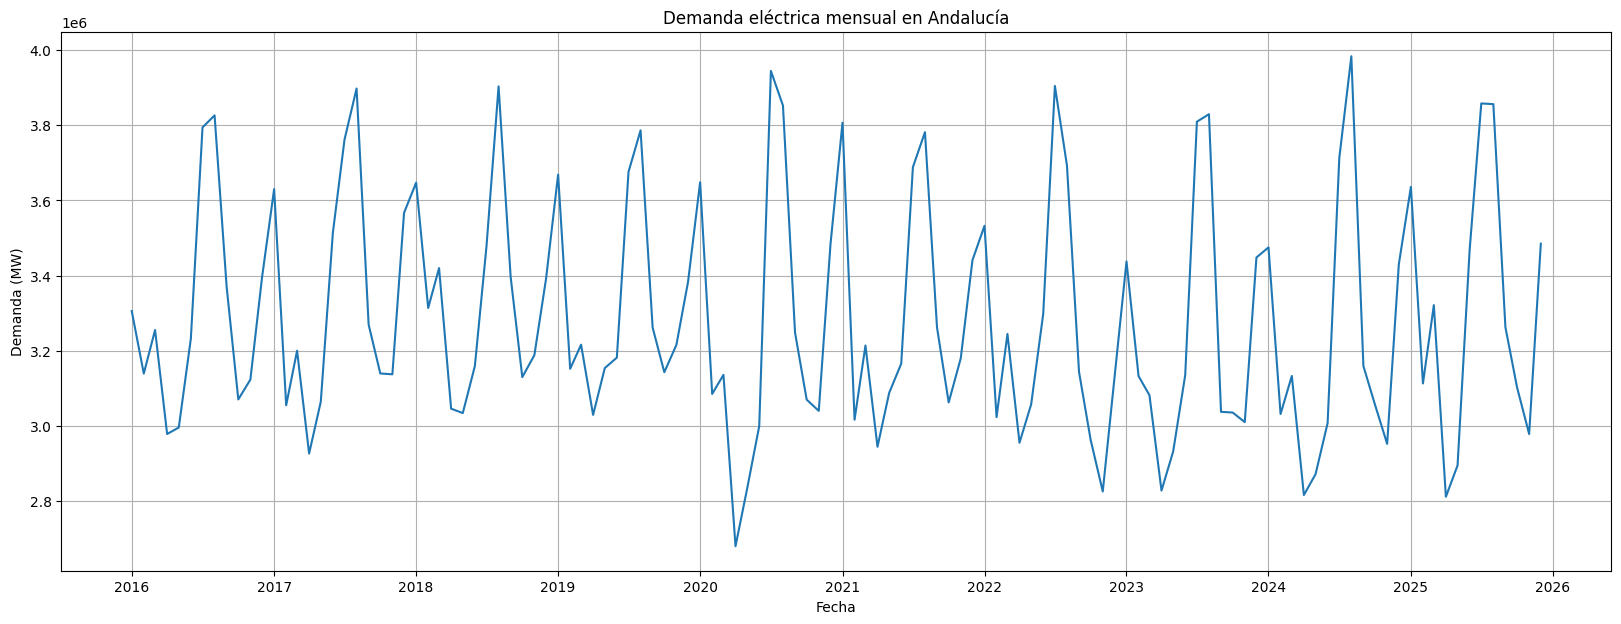

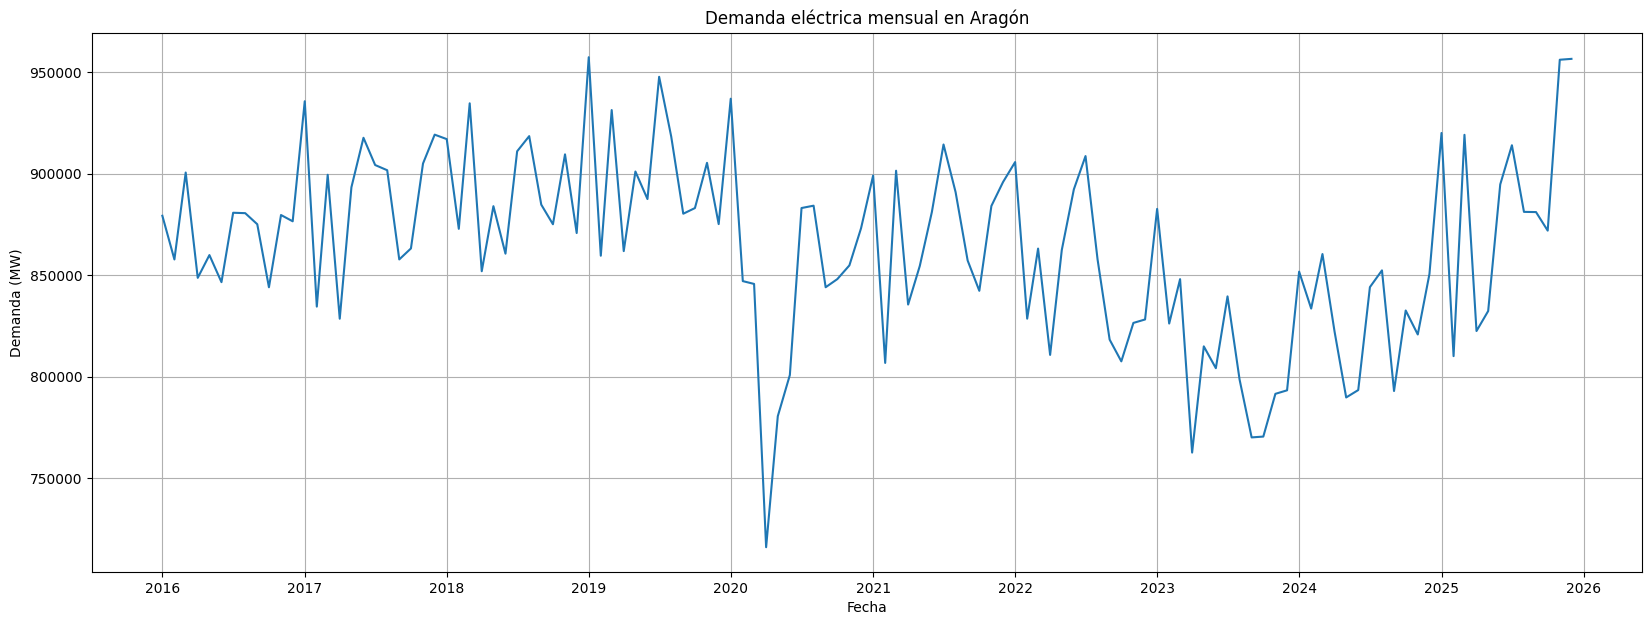

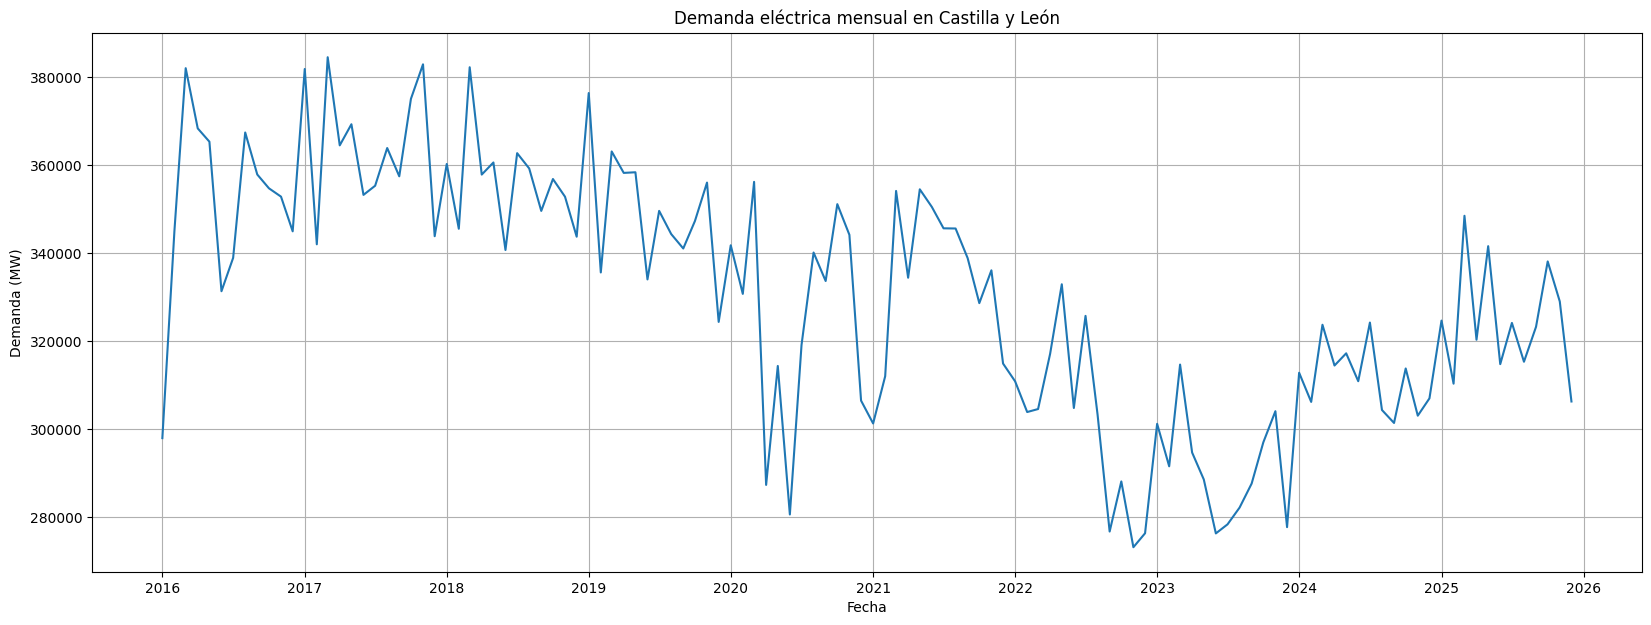

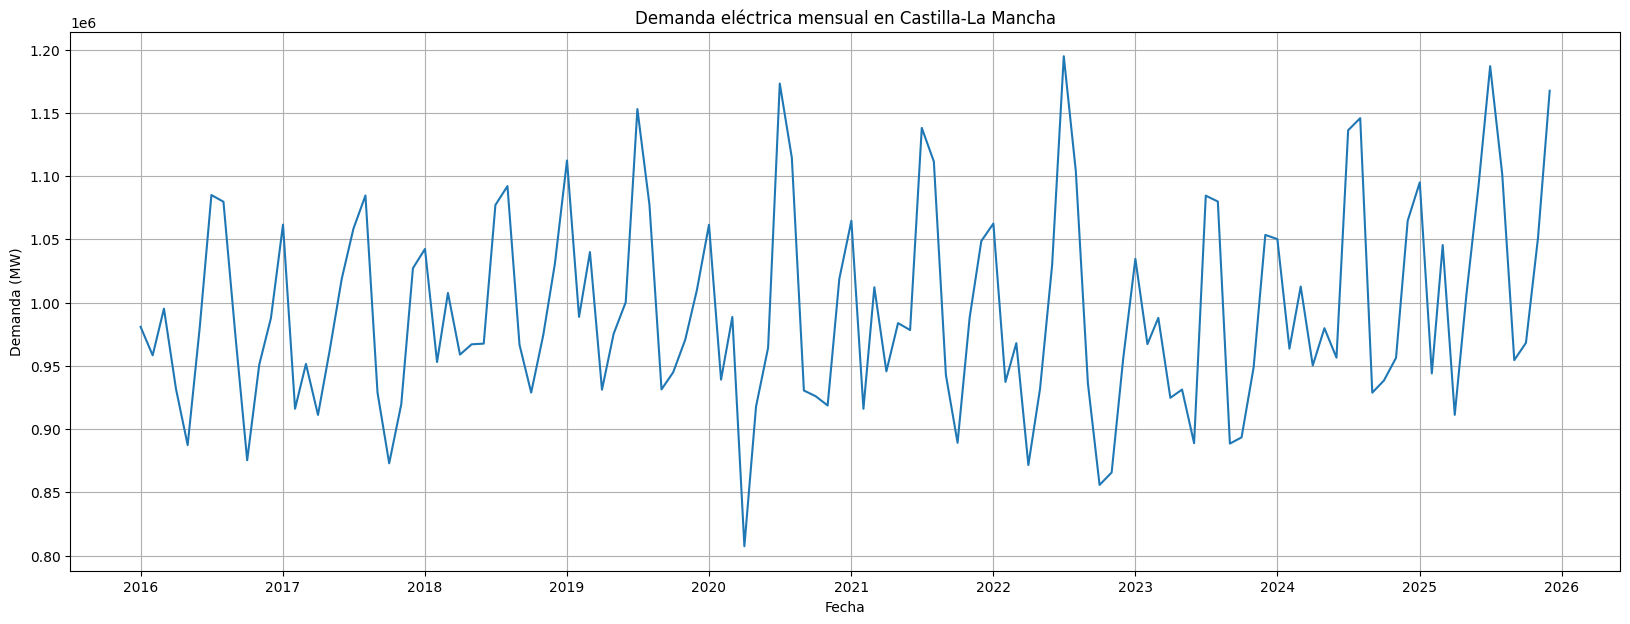

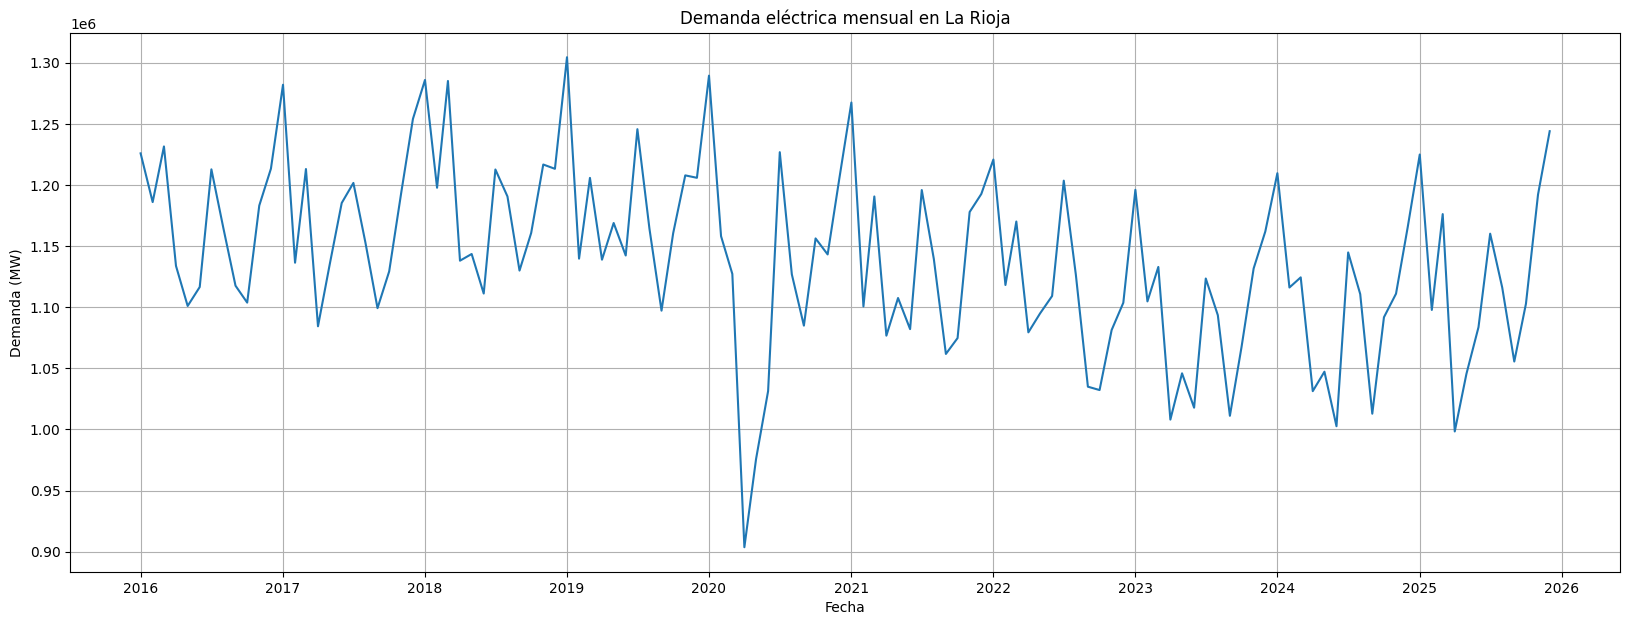

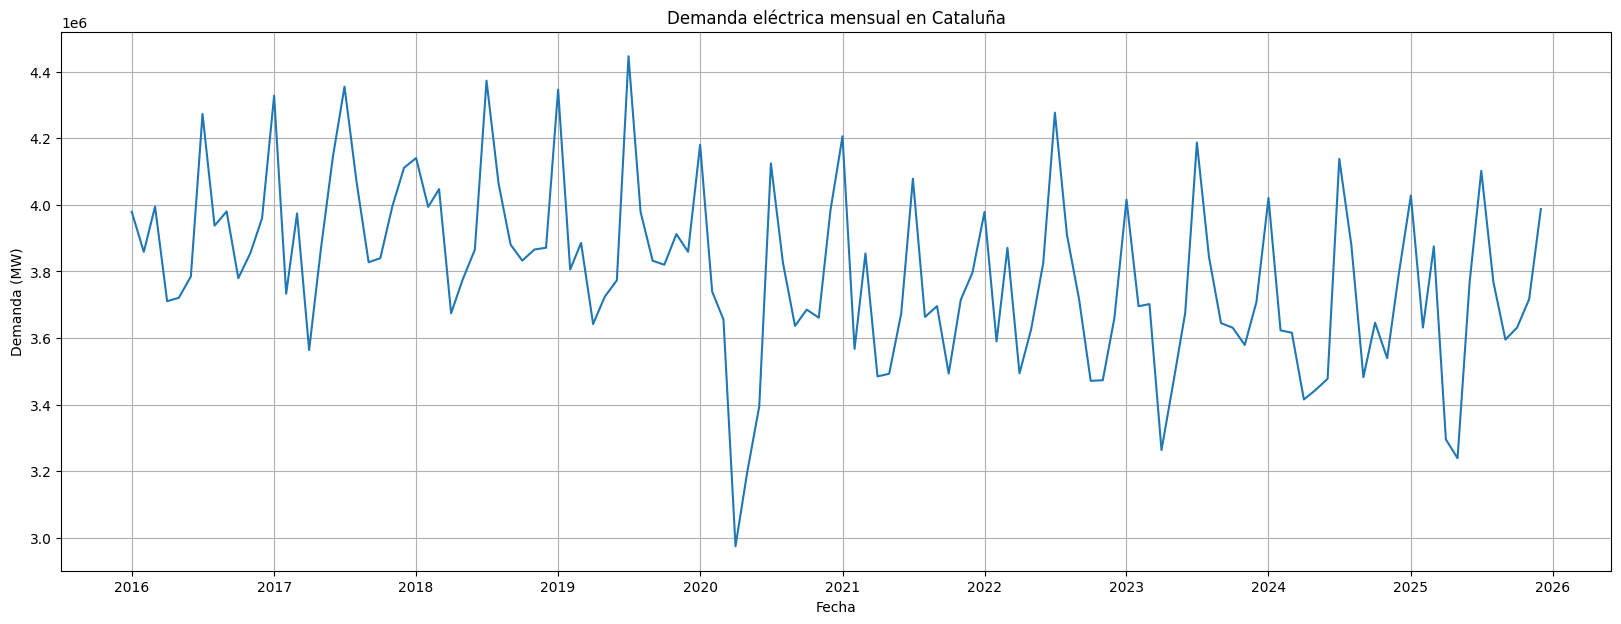

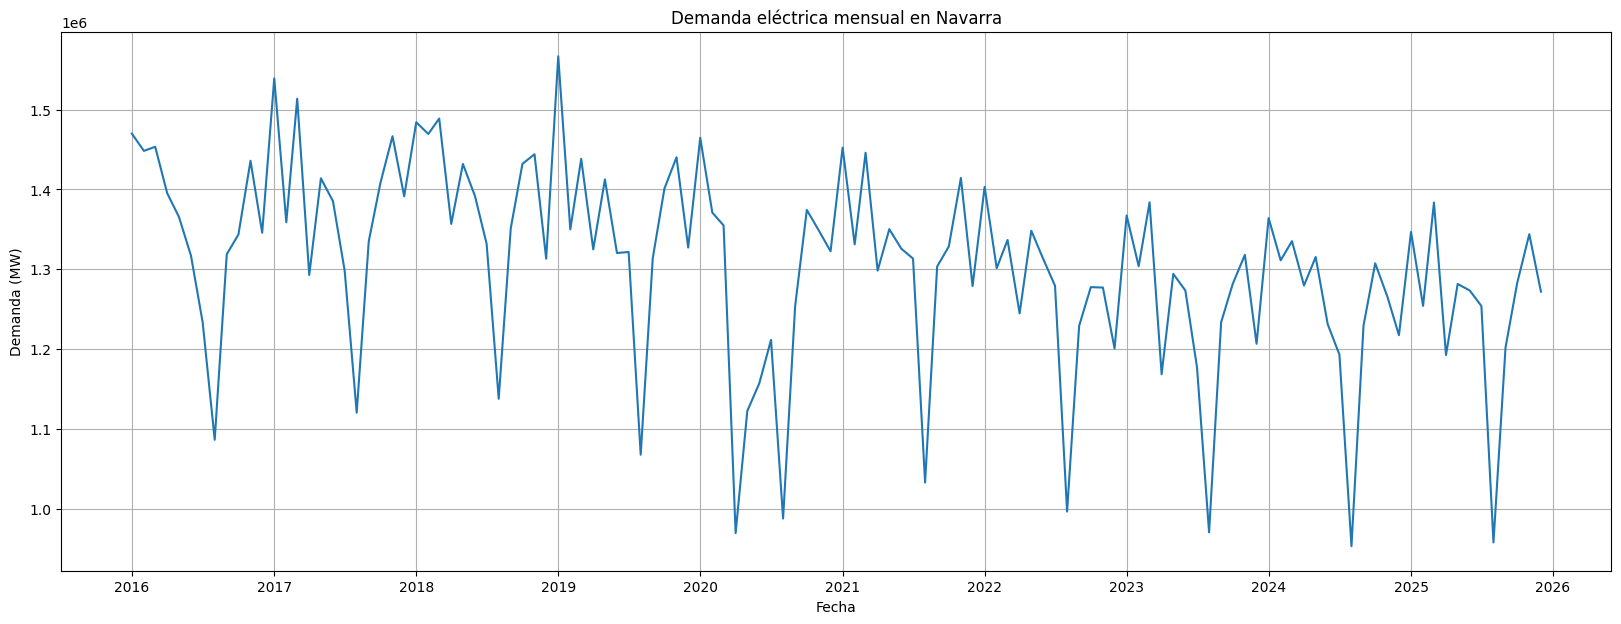

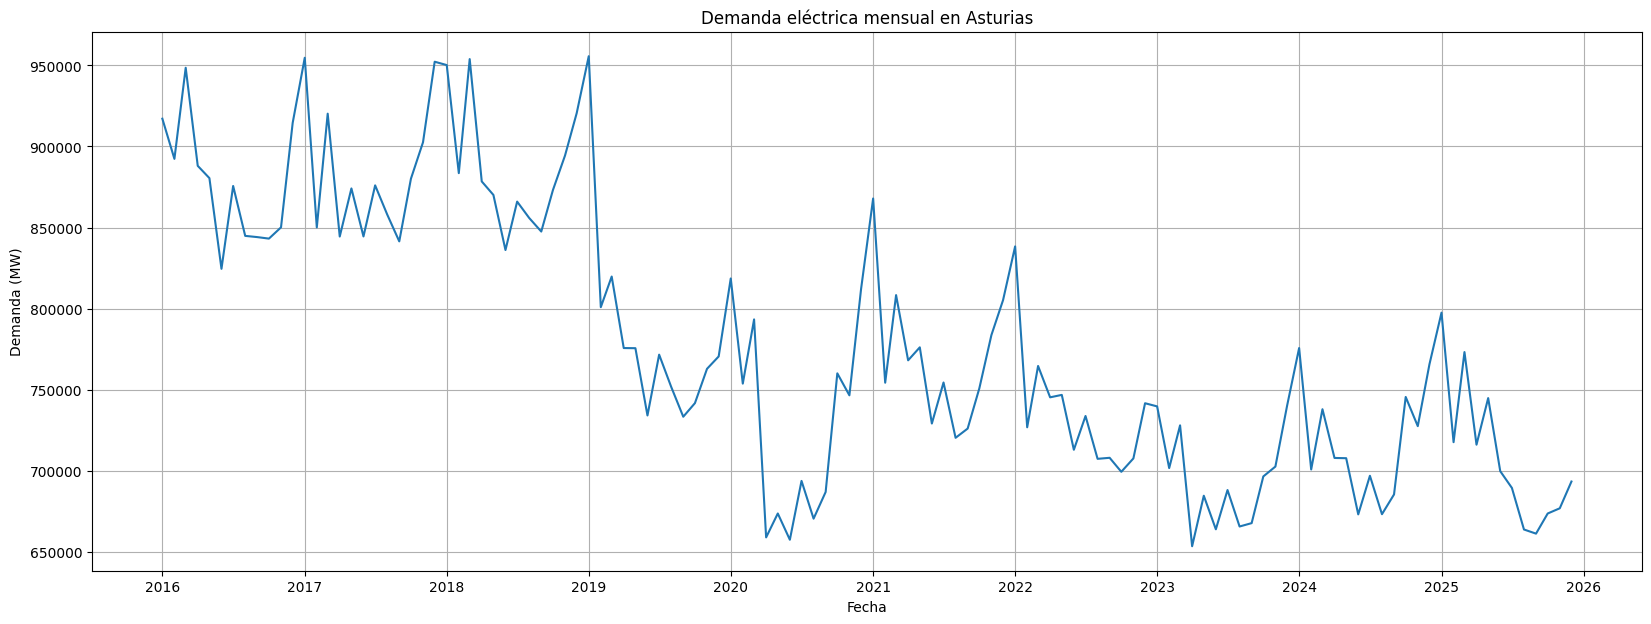

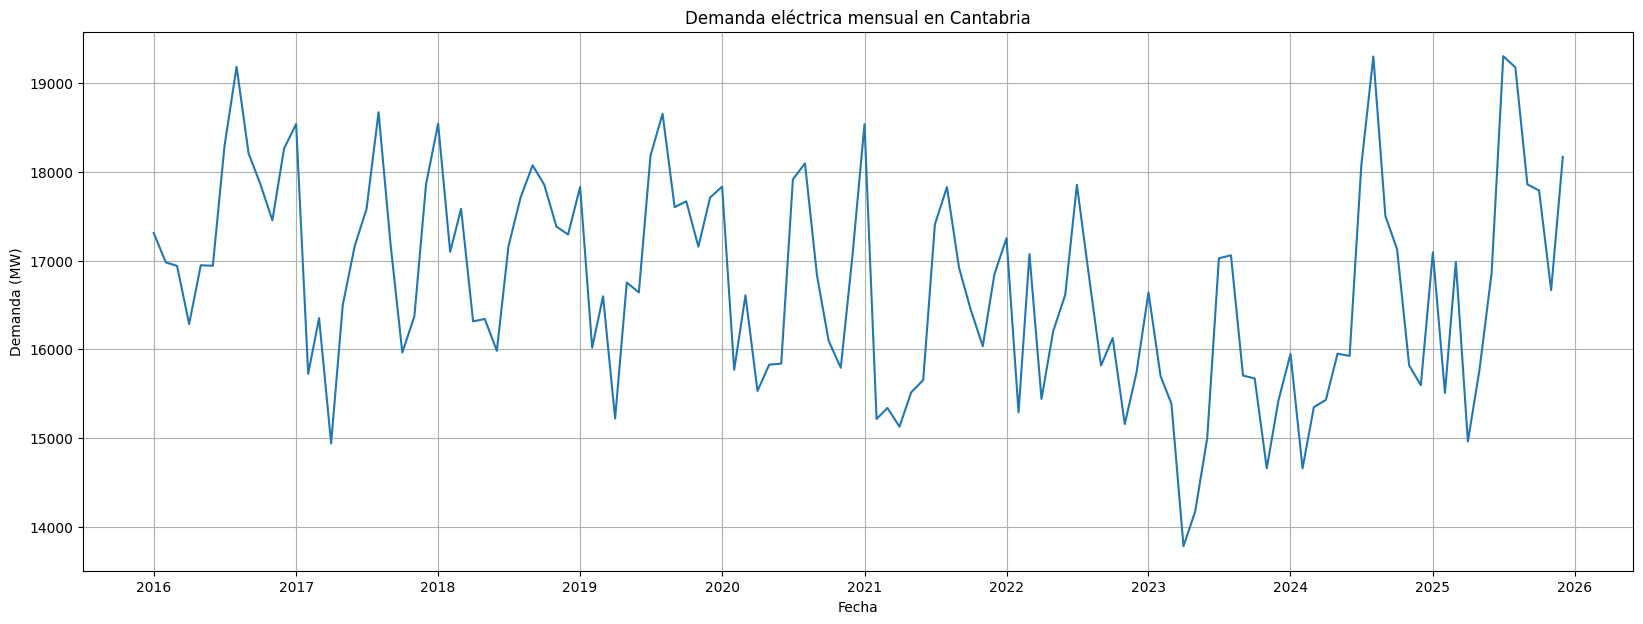

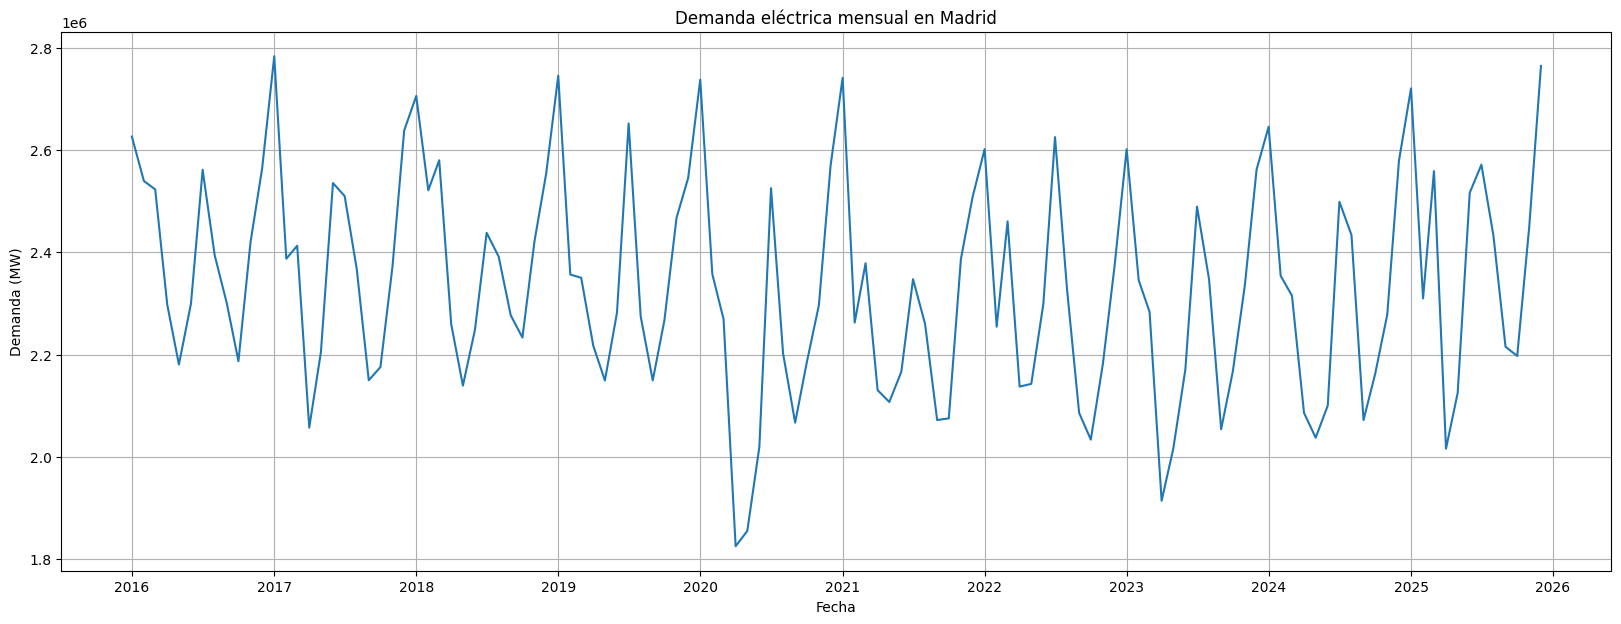

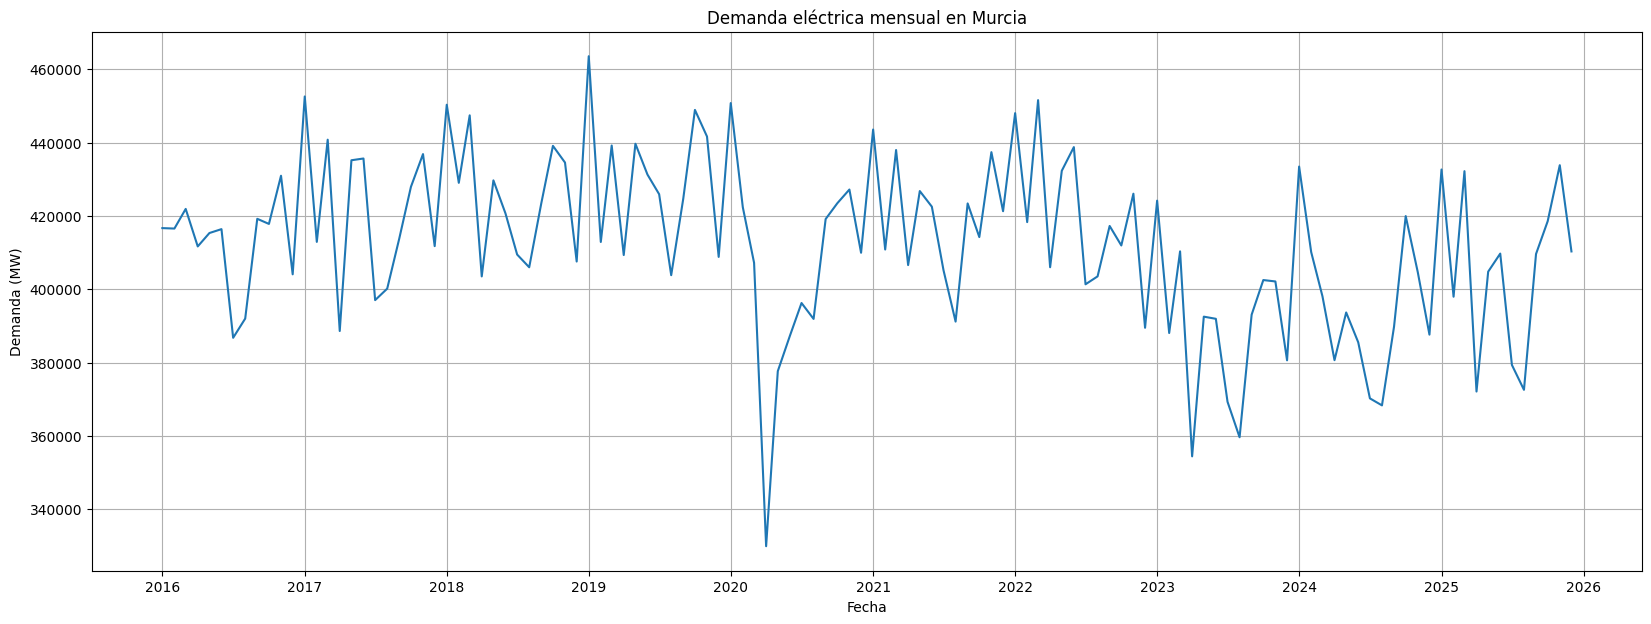

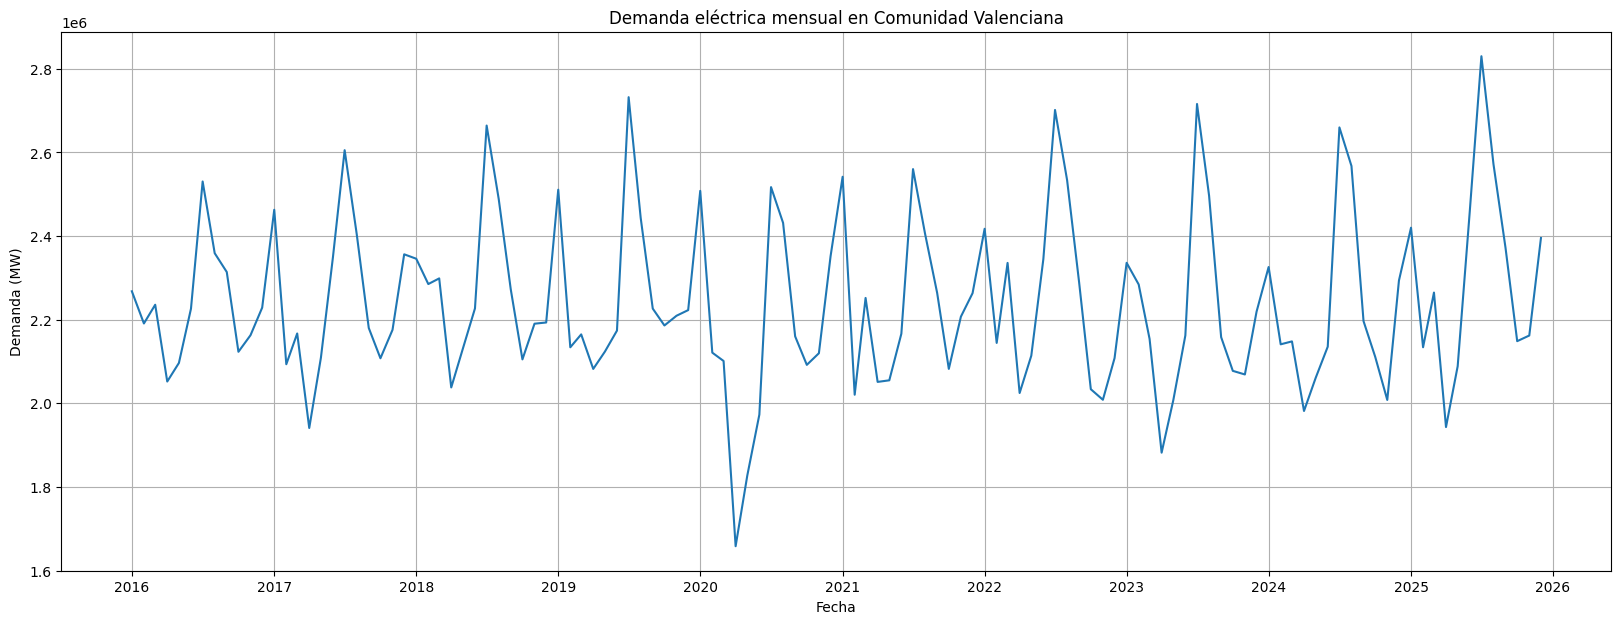

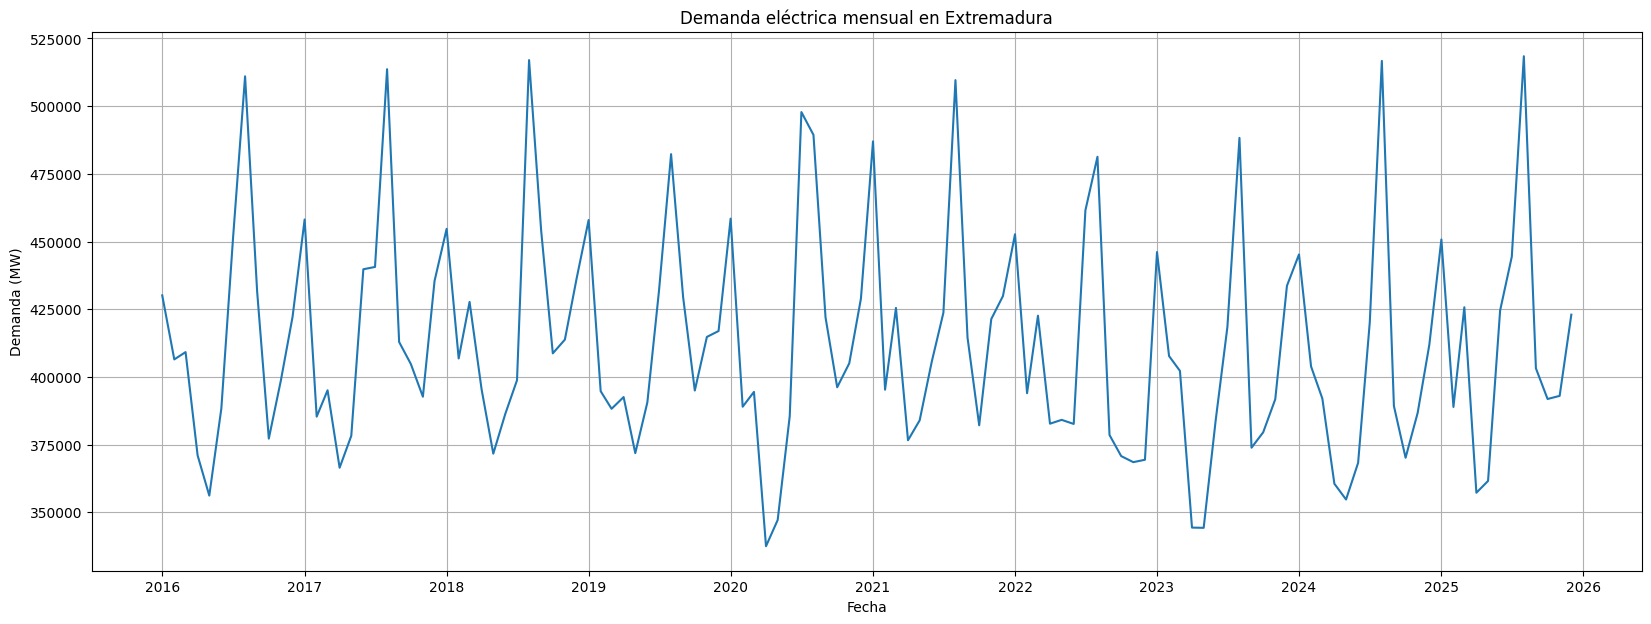

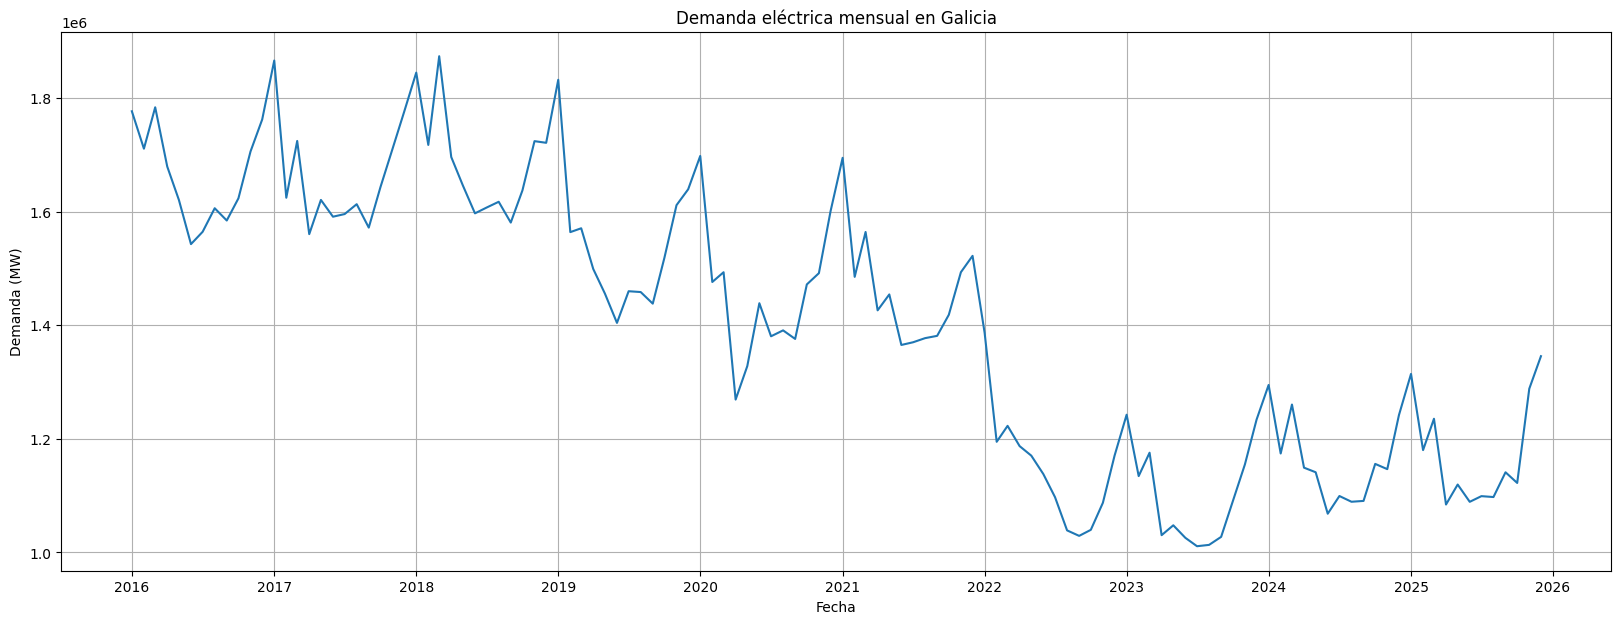

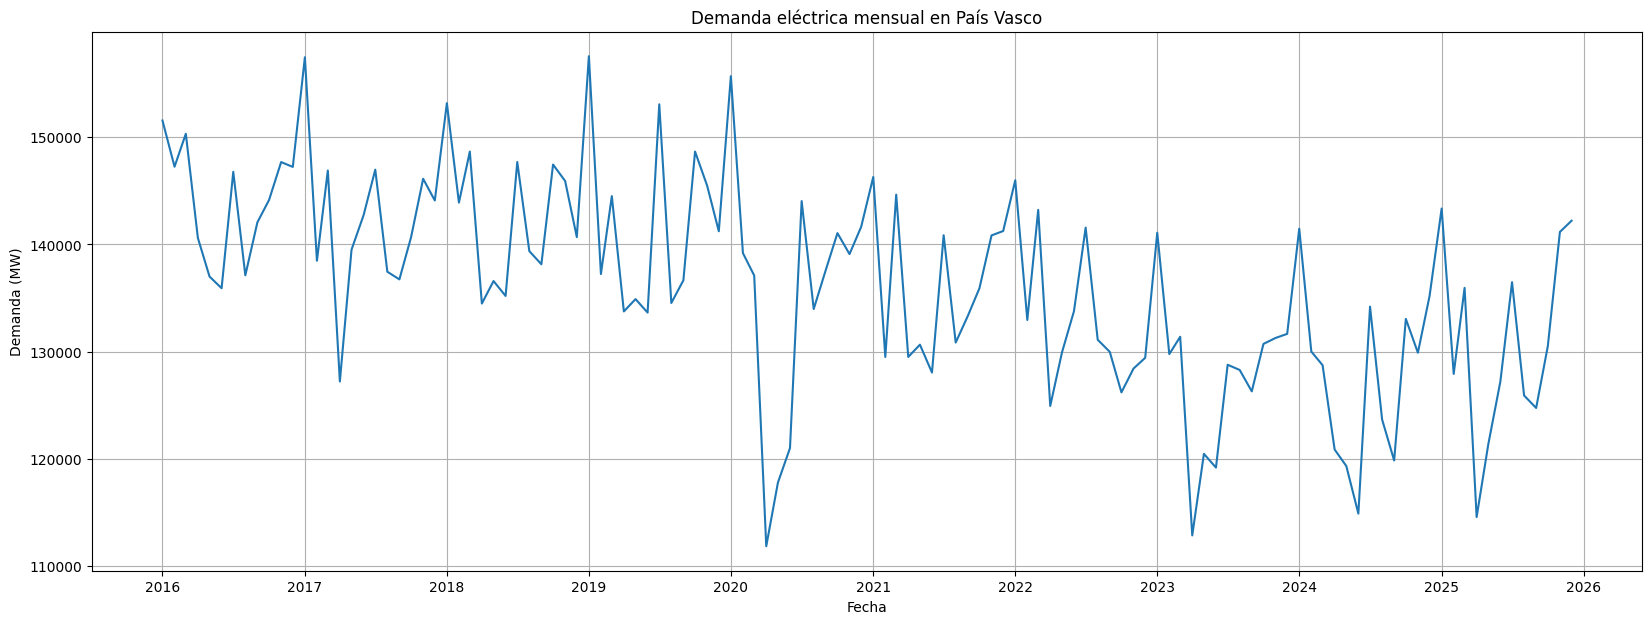

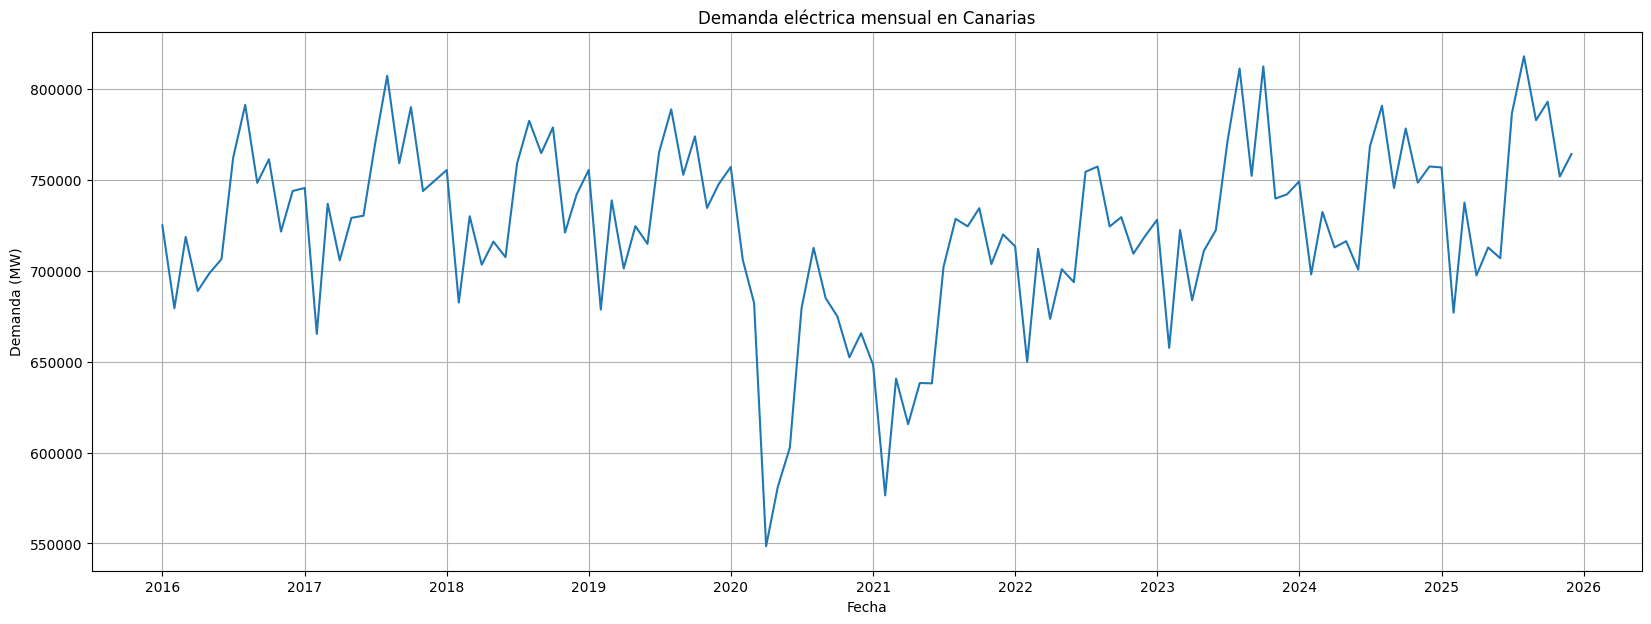

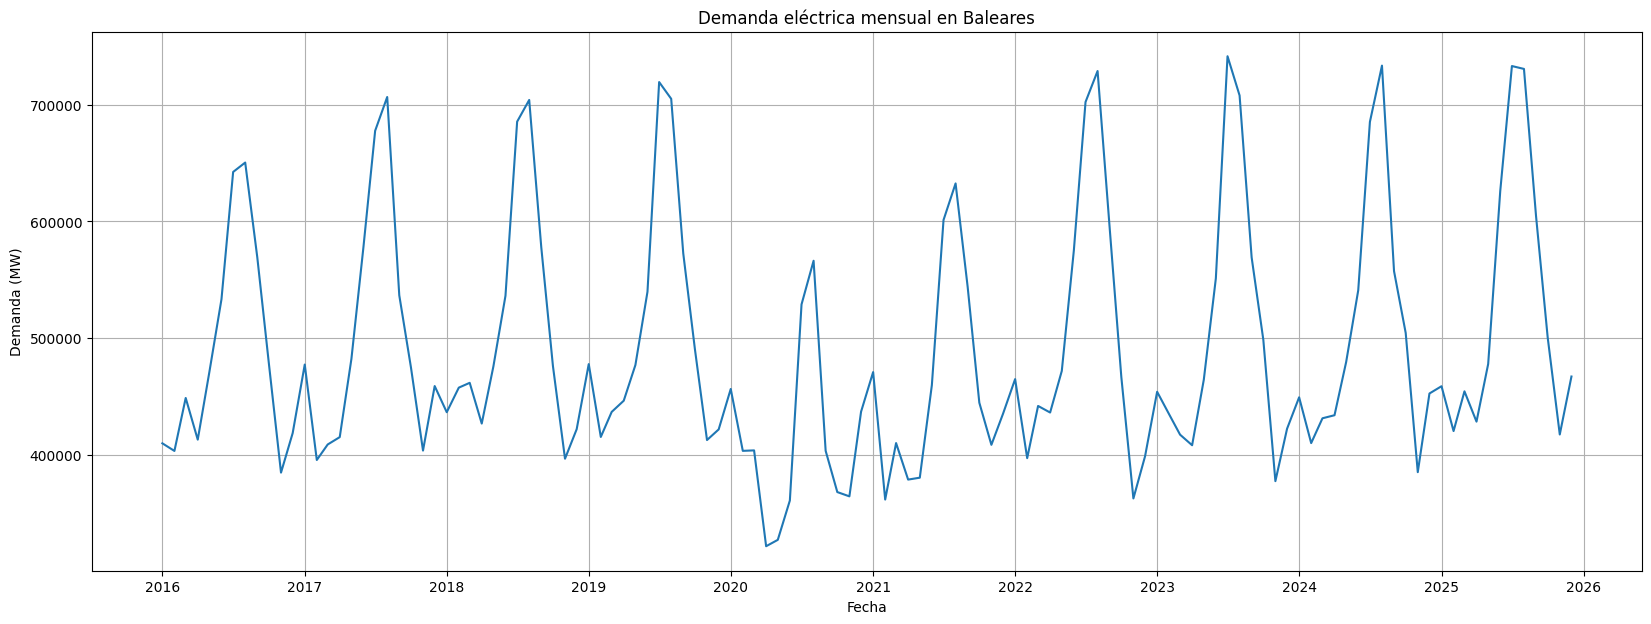

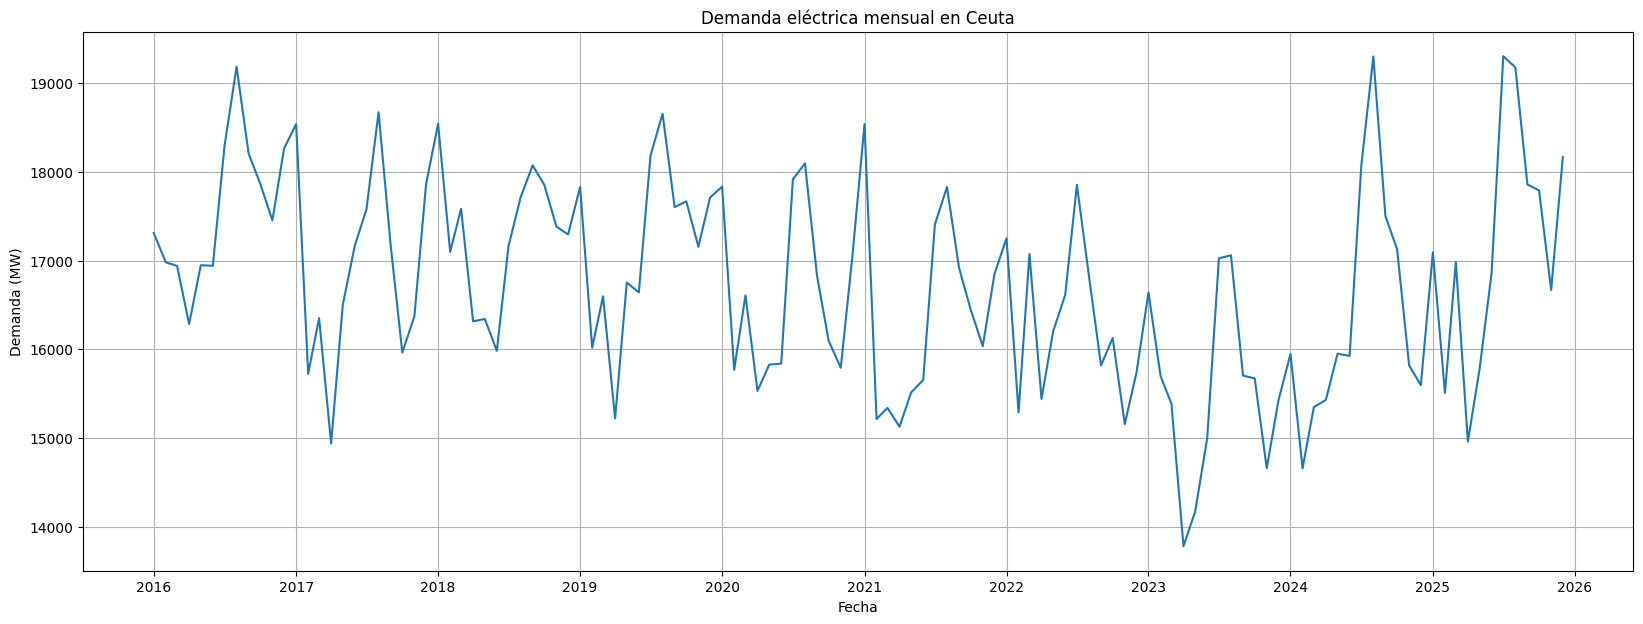

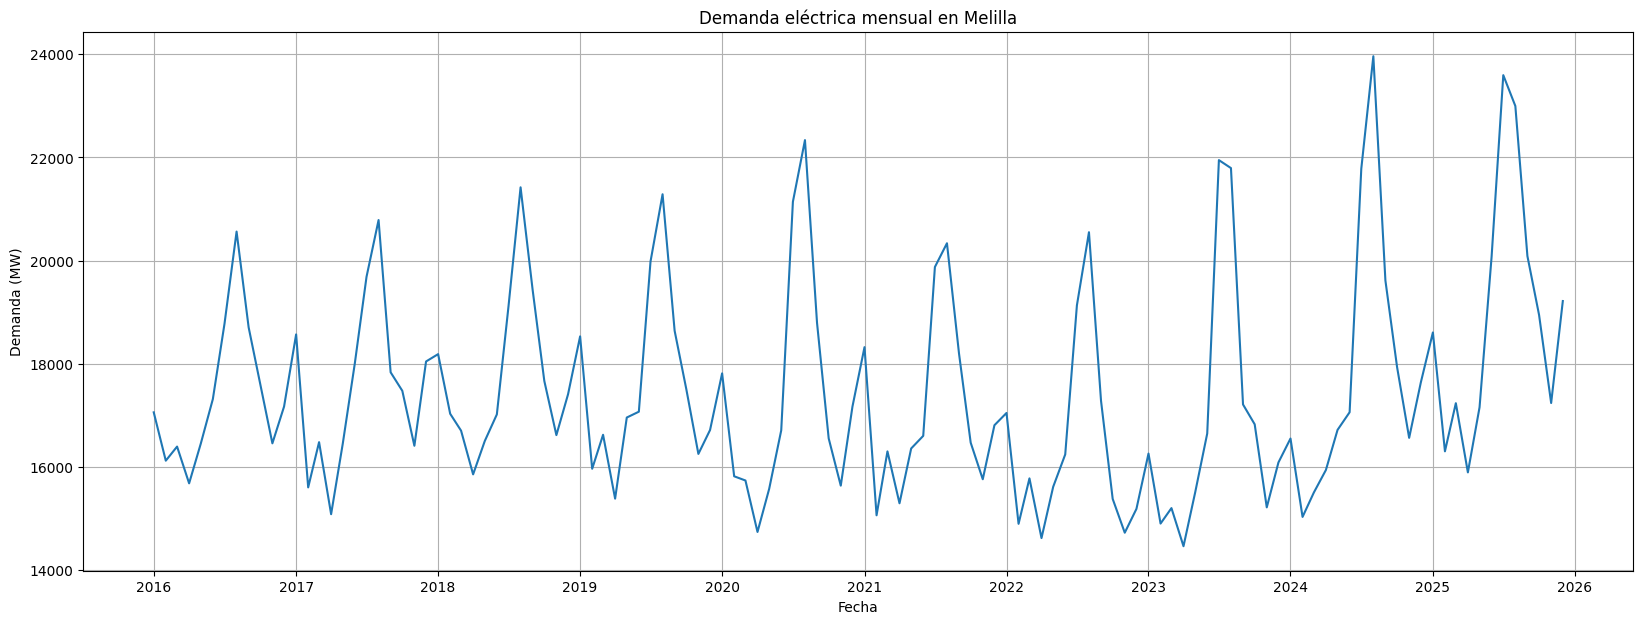

In [ ]:
#Imprimir un gáfico por region con la demanda eléctrica durante los 10 años
import matplotlib.pyplot as plt

for region in df_demanda_regional["region"].unique():
    
    temp = df_demanda_regional[
        df_demanda_regional["region"] == region
    ]
    
    plt.figure(figsize=(20,7))
    
    plt.plot(
        temp["datetime_spain"],
        temp["value"]
    )
    
    plt.title(f"Demanda eléctrica mensual en {region}")
    plt.xlabel("Fecha")
    plt.ylabel("Demanda (MW)")
    plt.grid(True)
    
    plt.show()

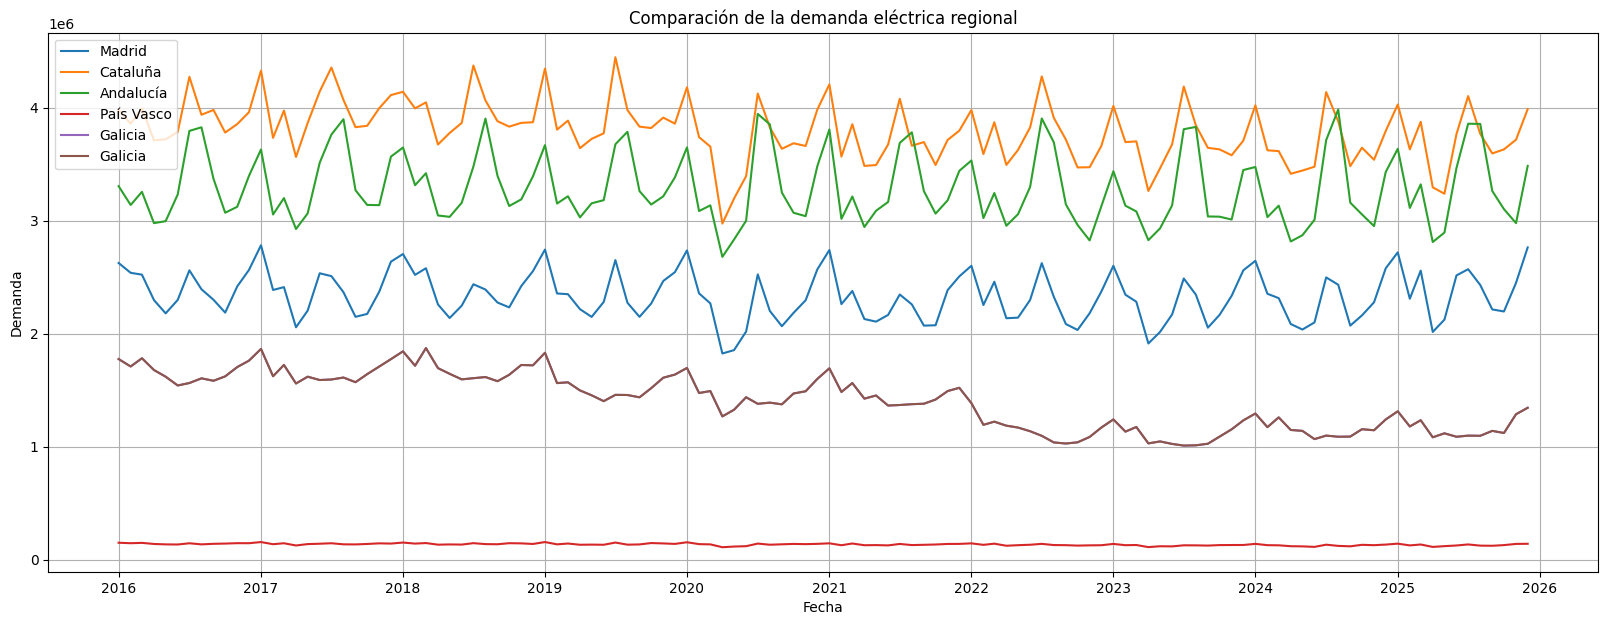

In [14]:
# crear gráficos con las regiones top consumo
regiones_top = [
    "Madrid",
    "Cataluña",
    "Andalucía",
    "País Vasco",
    "Galicia"
]

plt.figure(figsize=(20,7))

for region in regiones_top:

    temp = df_demanda_regional[
        df_demanda_regional["region"] == region
    ]

    plt.plot(
        temp["datetime_spain"],
        temp["value"],
        label=region
    )
    
plt.plot(
    temp["datetime_spain"],
    temp["value"],
    label=region
    )
    
plt.title("Comparación de la demanda eléctrica regional")
plt.xlabel("Fecha")
plt.ylabel("Demanda")
plt.legend()
plt.grid(True)
    
plt.show()